In [1]:
import pandas as pd
df_ab_test = pd.read_csv(r"C:\Users\asus\Documents\CaseStudies-main\AB Testing\ab_test_click_data.csv")

In [4]:
#print(df_ab_test.head())
print(df_ab_test.describe())
print(df_ab_test.groupby("group").sum("click"))

            user_id         click
count  20000.000000  20000.000000
mean   10000.500000      0.405250
std     5773.647028      0.490953
min        1.000000      0.000000
25%     5000.750000      0.000000
50%    10000.500000      0.000000
75%    15000.250000      1.000000
max    20000.000000      1.000000
         user_id  click
group                  
con    150005000   1989
exp     50005000   6116


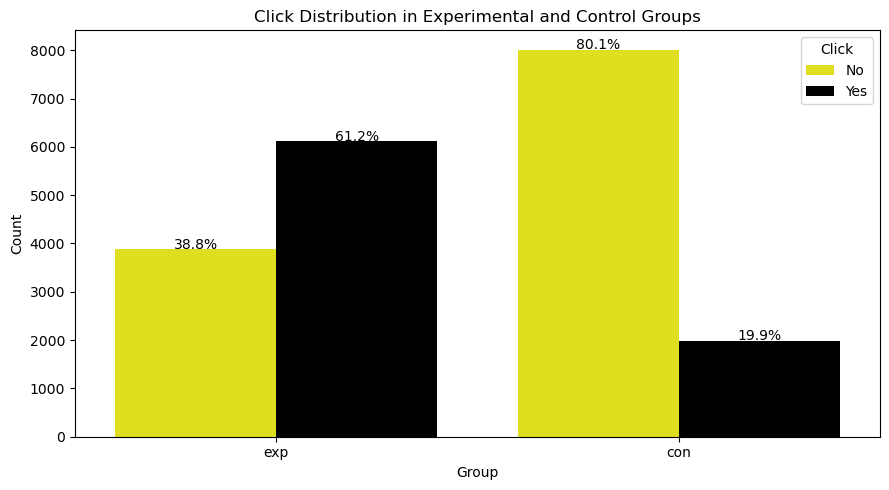

In [14]:
# custom palette for yellow and black
palette = {0: 'yellow', 1: 'black'}        # Assuming 0 is for no-click, 1 for click

# plotting the click distribution for each group with the custom colors
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize =(9, 5))
ax = sns.countplot(x = 'group', hue='click', data=df_ab_test, palette=palette)
plt.title('Click Distribution in Experimental and Control Groups')
plt.xlabel('Group')
plt.ylabel('Count')
plt.legend(title='Click', labels=['No', 'Yes'])

# calculate the percentages and annotate the bars
group_counts = df_ab_test.groupby (['group']).size()
froup_click_counts = df_ab_test.groupby(['group', 'click']).size().reset_index(name='count')

for p in ax.patches:
    height = p.get_height()
    # find the group and click type for the current bar
    group = 'exp' if p.get_x() < 0.5 else 'con'
    click = 1 if p.get_x() % 1 > 0.5 else 0
    total = group_counts.loc[group]
    percentage = 100 * height / total
    ax.text(p.get_x() + p.get_width() / 2., height + 5, f'{percentage:.1f}%', ha="center", color='black', fontsize=10)
    

plt.tight_layout()
plt.show()